# XLNet：情绪分类（快速学习 / 全量训练）

## ⭐ 先调整下一节的训练参数

默认 `TRAIN_MODE = "quick"`：分层抽取 **160 条训练数据，训练 1 轮**。
改成 `"full"`：使用全部清洗后的训练数据，默认训练 3 轮。
验证集和测试集始终保留全量；快速模式用于检查流程，不能期待之前全量模型的准确率。

流程：配置 → 读取 → 清洗审计 → 标签编码 → 分词 → 选择训练样本 → 微调 → 评估 → 保存 → 重载预测。
请从上到下执行；修改配置后，重新运行后续单元。环境变量变更则需重启内核。
每次输出目录独立，已有模型不会被覆盖。旧输出如尚未重跑，仅代表上次运行，不代表新配置结果。


In [1]:
# 标准库：路径、文件校验和当前环境配置。
from pathlib import Path
import hashlib
import re  # 用正则表达式删除 @用户名，避免误删邮箱中的 @。
import os
# 必须在导入 transformers / huggingface_hub 前设置；修改后重启内核。
# 禁止加载 .bin 时启动后台 safetensors 转换下载；不影响训练后安全格式保存。
os.environ["DISABLE_SAFETENSORS_CONVERSION"] = "1"
# 下载使用普通 HTTP，并关闭下载组件进度条，避免后台线程耗尽 Jupyter 通信句柄。
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"  # 当前 Windows 环境避免 OpenMP 冲突。

import numpy as np  # 分位数、长度统计和随机种子。
import pandas as pd  # 读取 CSV、检查标签、统计与数据整理。
import matplotlib.pyplot as plt  # 标签分布与长度可视化。
from IPython.display import display  # 显式展示多张表格。
from cleantext import clean  # clean-text 的文本修复函数，下面显式关闭小写和 ASCII 转换。
import transformers  # 预训练模型与 tokenizer 接口。
transformers.utils.logging.disable_progress_bar()  # 权重加载/保存也不创建交互式组件。
from transformers import AutoTokenizer, XLNetModel, DataCollatorWithPadding
import torch  # 张量、批次及模型前向计算。
import sklearn  # 后续分类评估使用；本阶段已有划分，无需 train_test_split。
import datasets  # Hugging Face Arrow 数据集。
datasets.disable_progress_bars()  # 数据预处理不使用 widget 进度条。
from datasets import Dataset, DatasetDict, Features, Value, ClassLabel

print({"torch": torch.__version__, "transformers": transformers.__version__,
       "datasets": datasets.__version__, "sklearn": sklearn.__version__})

# 微调、评估与保存：Trainer 负责训练循环，sklearn 直接计算指标，无需下载指标脚本。
from transformers import XLNetForSequenceClassification, Trainer, TrainingArguments, TrainerCallback, set_seed
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from datetime import datetime  # 每次训练使用独立目录，避免覆盖已有模型。
import json  # 保存预处理参数及评估结果。
import gc  # 释放演示用模型，避免同时保留两份 XLNet。
from sklearn.model_selection import train_test_split  # 只对训练集抽样，不重划分验证/测试集。
from time import monotonic  # 单调时钟，用于显示耗时。


Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


{'torch': '2.13.0+cpu', 'transformers': '5.16.1', 'datasets': '5.0.1', 'sklearn': '1.9.0'}


## 1. ⭐ 参数控制面板（主要改这里）

`QUICK_TRAIN_SAMPLES` 控制快速模式样本数；`QUICK_EPOCHS` / `FULL_EPOCHS` 控制轮数。
`LOG_EVERY_STEPS` 控制纯文本进度输出频率。恢复 checkpoint 时必须保持训练模式、样本数、随机种子和批次配置一致。

In [2]:
# ================= ⭐ 日常调整区 =================
TRAIN_MODE = "quick"       # "quick"：快速学习；"full"：正式全量训练
QUICK_TRAIN_SAMPLES = 160  # 快速模式训练样本总数，不是每类数量
QUICK_EPOCHS = 1           # 快速检查流程，不用于追求最佳准确率
FULL_EPOCHS = 3            # 全量模式保留原来的 3 轮设置
LOG_EVERY_STEPS = 5        # 每 5 个优化器步骤输出一次百分比/耗时
RUN_EMBEDDING_DEMO = False # 可选教学演示，分类微调不依赖此步骤
RESUME_CHECKPOINT = None   # 仅填写自己保存且配置匹配的 checkpoint 路径

# ================= 稳定配置区 =================
MODEL_NAME = "xlnet/xlnet-base-cased"
SEED = 42
BATCH_SIZE = 2             # 仅用于动态 padding / embedding 演示
TRAIN_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4  # 单设备等效批次约为 4 × 4 = 16
MAX_LENGTH_CAP = 256       # 字符分词后的 token 上限，不是模型绝对长度上限
DATA_FILES = {
    "train": Path("emotion-labels-train.csv"),
    "validation": Path("emotion-labels-val.csv"),
    "test": Path("emotion-labels-test.csv"),
}
if TRAIN_MODE not in {"quick", "full"}:
    raise ValueError('TRAIN_MODE 只能为 "quick" 或 "full"。')
for name, value in {
    "QUICK_TRAIN_SAMPLES": QUICK_TRAIN_SAMPLES, "QUICK_EPOCHS": QUICK_EPOCHS,
    "FULL_EPOCHS": FULL_EPOCHS, "LOG_EVERY_STEPS": LOG_EVERY_STEPS,
    "TRAIN_BATCH_SIZE": TRAIN_BATCH_SIZE, "GRADIENT_ACCUMULATION_STEPS": GRADIENT_ACCUMULATION_STEPS,
}.items():
    if type(value) is not int or value <= 0:
        raise ValueError(f"{name} 必须为正整数。")
NUM_EPOCHS = QUICK_EPOCHS if TRAIN_MODE == "quick" else FULL_EPOCHS
set_seed(SEED)  # 统一设置 Python、NumPy 和 PyTorch 随机种子
print(f"当前模式：{TRAIN_MODE}；训练轮数：{NUM_EPOCHS}；验证/测试：全量", flush=True)

# 只读原始文件；保留哈希用于最后确认文件未被预处理覆盖。
source_hashes = {split: hashlib.sha256(path.read_bytes()).hexdigest()
                 for split, path in DATA_FILES.items()}
raw_frames = {split: pd.read_csv(path) for split, path in DATA_FILES.items()}
for split, frame in raw_frames.items():
    if not {"text", "label"}.issubset(frame.columns):
        raise ValueError(f"{DATA_FILES[split]} 必须包含 text 和 label 列。")
    print(split, frame.shape)
    display(frame.head(3))


当前模式：quick；训练轮数：1；验证/测试：全量


train (3613, 2)


,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy


validation (347, 2)


,text,label
0,"@theclobra lol I thought maybe, couldn't decid...",joy
1,Nawaz Sharif is getting more funnier than @kap...,joy
2,Nawaz Sharif is getting more funnier than @kap...,joy


test (3142, 2)


,text,label
0,You must be knowing #blithe means (adj.) Happ...,joy
1,Old saying 'A #smile shared is one gained for ...,joy
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy


## 2. 轻量清洗与数据审计

删除 @用户名和 emoji 表情，修复 Unicode 并合并空白；保留大小写、其他标点、停用词和词形。删除表情也会丢失部分情绪信号，这是本次选用的清洗规则。`raw_text` 保存原文。

重复检查以清洗后的文本完全一致为准，不进行模糊匹配。同一文本有多个标签时，隔离其所有样本，供人工核查；其余重复优先保留 test，再 validation，再 train，避免训练集包含评估文本。原始划分仍可在 `raw_frames` 查看，排除记录保存在 `excluded_rows`。

In [3]:
def clean_for_xlnet(text: str) -> str:
    """删除社交媒体用户名和 emoji，保留原有大小写与词形。"""
    # 用户名由英文字母、数字、下划线组成；前面的边界避免匹配邮箱。
    # 替换为空格而非空字符串，防止相邻词语拼接到一起。
    # no_emoji=True 删除 Unicode emoji；不额外删除 :) 等字符表情。
    text = clean(text, lower=False, to_ascii=False, no_emoji=True,
                 no_punct=False, no_line_breaks=True)
    # 先规范化再删除用户名，确保全角 @ 等修复后的写法也能匹配。
    text = re.sub(r"(?<![\w@])@[A-Za-z0-9_]+", " ", text)
    return " ".join(text.split())

# 1. 建立副本并保留原文/来源，清洗后的行仍能追溯到 CSV。
prepared = []
for split, frame in raw_frames.items():
    part = frame.copy()
    part["source_row"] = part.index
    part["split"] = split
    part["raw_text"] = part["text"]
    part["text"] = part["text"].fillna("").map(clean_for_xlnet)
    prepared.append(part)
all_data = pd.concat(prepared, ignore_index=True)
all_data["exclude_reason"] = ""
# 2. 先隔离空文本/缺失标签，再隔离同一清洗文本的冲突标签。
invalid = all_data["text"].eq("") | all_data["label"].isna()
all_data.loc[invalid, "exclude_reason"] = "empty text / missing label"
valid = all_data.loc[~invalid]
conflicting_texts = valid.groupby("text")["label"].nunique().loc[lambda x: x > 1].index
all_data.loc[~invalid & all_data["text"].isin(conflicting_texts), "exclude_reason"] = "conflicting labels"

# 3. 按 test → validation → train 的顺序保留首条重复文本。
# 只处理未被隔离的行；向量化替代逐行 iterrows，保持原来的去重优先级。
eligible = all_data.loc[all_data["exclude_reason"].eq("")].copy()
eligible["_priority"] = eligible["split"].map({"test": 0, "validation": 1, "train": 2})
eligible = eligible.sort_values("_priority", kind="stable")
duplicates = eligible.index[eligible["text"].duplicated(keep="first")]
all_data.loc[duplicates, "exclude_reason"] = "duplicate cleaned text"

# 4. 分别生成可用数据和排除审计，不改写任何原始 CSV。
excluded_rows = all_data.loc[all_data["exclude_reason"].ne("")].copy()
clean_frames = {split: all_data.loc[(all_data["split"] == split) & all_data["exclude_reason"].eq("")].copy()
                for split in DATA_FILES}
audit_summary = pd.DataFrame({"Original": {s:len(f) for s,f in raw_frames.items()},
                             "Retained": {s:len(f) for s,f in clean_frames.items()}})
audit_summary["Excluded"] = audit_summary["Original"] - audit_summary["Retained"]
display(audit_summary)
display(excluded_rows.groupby(["split", "exclude_reason"]).size().rename("Count").to_frame())
display(all_data[["raw_text", "text", "label"]].head(3))

,Original,Retained,Excluded
train,3613,3373,240
validation,347,330,17
test,3142,2963,179


Count
split      exclude_reason               
test       conflicting labels        176
           duplicate cleaned text      3
train      conflicting labels        193
           duplicate cleaned text     47
validation conflicting labels         17

,raw_text,text,label
0,Just got back from seeing @GaryDelaney in Burs...,Just got back from seeing in Burslem. AMAZING!...,joy
1,Oh dear an evening of absolute hilarity I don'...,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,Been waiting all week for this game #cheer #fr...,joy


## 3. 标签与文本长度可视化

这里展示处理后的数据；长度为字符数，后续另统计 tokenizer 长度。

split,train,validation,test
label,,,
anger,804,80,724
fear,1100,105,942
joy,770,78,708
sadness,699,67,589


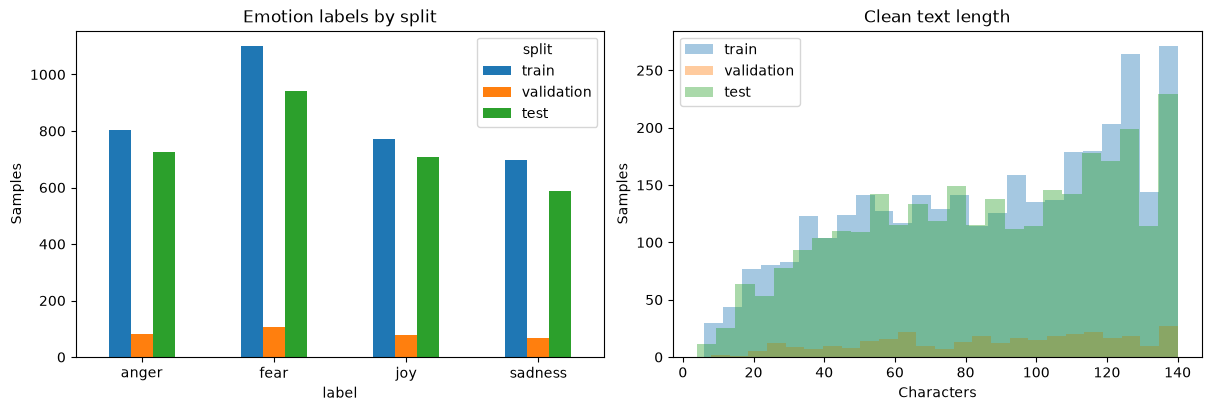

In [4]:
# 可视化全部清洗数据，而不是快速模式的抽样子集。
# 左图检查各类数量，右图观察字符长度；字符数与 token 数不同。
clean_all = pd.concat(clean_frames.values(), ignore_index=True)
label_counts = pd.crosstab(clean_all["label"], clean_all["split"]).reindex(columns=list(DATA_FILES), fill_value=0)
display(label_counts)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
label_counts.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Emotion labels by split")
axes[0].set_ylabel("Samples")
for split, frame in clean_frames.items():
    axes[1].hist(frame["text"].str.len(), bins=25, alpha=0.4, label=split)
axes[1].set_title("Clean text length")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Samples")
axes[1].legend()
plt.show()

## 4. 标签数字化与 DatasetDict

只从训练标签建立稳定的字母排序映射，验证/测试必须使用同一映射。ClassLabel 保存编号与名称。

In [5]:
# 类别映射始终来自完整训练集，不能因快速抽样而改变编号。
label_names = sorted(clean_frames["train"]["label"].unique().tolist())
label2id = {label: index for index, label in enumerate(label_names)}
id2label = {index: label for label, index in label2id.items()}
# 显式声明字段类型，避免不同 split 的 label 类型不一致。
features = Features({"text": Value("string"), "raw_text": Value("string"),
                     "label": ClassLabel(names=label_names), "source_row": Value("int64")})
dataset = DatasetDict()
for split, frame in clean_frames.items():
    assert set(frame["label"]).issubset(label2id), "评估集中有训练集未出现的标签"
    encoded = frame[["text", "raw_text", "label", "source_row"]].copy()
    encoded["label"] = encoded["label"].map(label2id)
    dataset[split] = Dataset.from_pandas(encoded, features=features, preserve_index=False)
print(label2id)
print(dataset)
display(dataset["train"][0])

{'anger': 0, 'fear': 1, 'joy': 2, 'sadness': 3}
DatasetDict({
    train: Dataset({
        features: ['text', 'raw_text', 'label', 'source_row'],
        num_rows: 3373
    })
    validation: Dataset({
        features: ['text', 'raw_text', 'label', 'source_row'],
        num_rows: 330
    })
    test: Dataset({
        features: ['text', 'raw_text', 'label', 'source_row'],
        num_rows: 2963
    })
})


{'text': 'Just got back from seeing in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious',
 'raw_text': 'Just got back from seeing @GaryDelaney in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious',
 'label': 2,
 'source_row': 0}

## 5. XLNet tokenizer 与截断长度

使用 base-cased 对应分词器，保留模型默认特殊 Token 和左侧 padding。只根据训练集的分词长度 95% 分位数选择长度，向上取到 8 的倍数，并受预算上限约束。长度包含特殊 Token。

各集合截断比例用于审计，不用验证/测试长度修改训练参数。

训练集长度 P50/P95/P99：[27.   45.   55.28]；MAX_LENGTH=48
Padding side: left


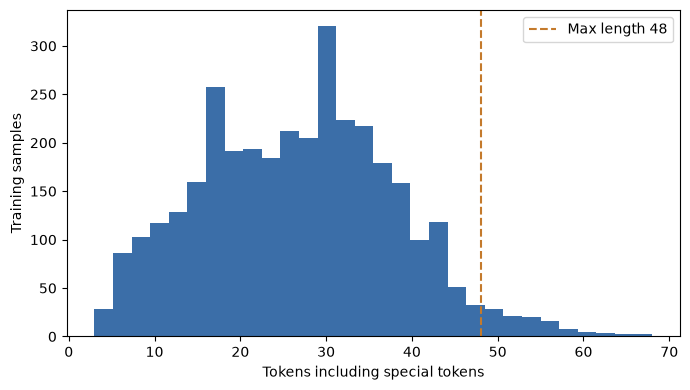

,Split,Truncated (%)
0,train,3.201897
1,validation,4.848485
2,test,2.936213


{'text': 'Just got back from seeing in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious',
 'raw_text': 'Just got back from seeing @GaryDelaney in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious',
 'label': 2,
 'source_row': 0,
 'input_ids': [1641,
  345,
  126,
  40,
  2531,
  25,
  3571,
  23,
  12849,
  9,
  8239,
  14338,
  5103,
  7675,
  12274,
  194,
  1990,
  23,
  40,
  9186,
  102,
  178,
  17,
  7967,
  11729,
  617,
  4672,
  4,
  3],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1]}

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Dataset 的列对象显式转为 list，兼容 tokenizer 的批量文本接口。
# 每个集合的长度只计算一次；选截断长度仅使用完整训练集，避免测试信息泄漏。
token_lengths = {
    split: np.array([len(ids) for ids in tokenizer(list(part["text"]), truncation=False)["input_ids"]])
    for split, part in dataset.items()
}
train_lengths = token_lengths["train"]
MAX_LENGTH = min(MAX_LENGTH_CAP, max(8, int(np.ceil(np.percentile(train_lengths, 95) / 8) * 8)))
print(f"训练集长度 P50/P95/P99：{np.percentile(train_lengths, [50,95,99])}；MAX_LENGTH={MAX_LENGTH}")
print(f"Padding side: {tokenizer.padding_side}")
plt.figure(figsize=(7, 4))
plt.hist(train_lengths, bins=30, color="#3B6EA8")
plt.axvline(MAX_LENGTH, color="#C47A2C", linestyle="--", label=f"Max length {MAX_LENGTH}")
plt.xlabel("Tokens including special tokens")
plt.ylabel("Training samples")
plt.legend()
plt.tight_layout()
plt.show()

def tokenize_batch(batch):
    """只截断，暂不补齐；padding 留给 DataCollator，减少无用计算。"""
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
length_audit = []
for split in dataset:
    lengths = token_lengths[split]
    length_audit.append({"Split": split, "Truncated (%)": np.mean(np.array(lengths) > MAX_LENGTH) * 100})
display(pd.DataFrame(length_audit))
display(tokenized_dataset["train"][0])

## 6. 动态 padding 与小批次

保留带原文的 Dataset 供检查，另创建只含模型字段的 `model_dataset`。collator 把 `label` 改为模型需要的 `labels`，并按批次最长序列补齐。


In [7]:
model_dataset = tokenized_dataset.remove_columns(["text", "raw_text", "source_row"])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
# 演示只需要一个批次，直接调用 collator，无需额外创建 DataLoader。
batch = data_collator([model_dataset["train"][i] for i in range(min(BATCH_SIZE, len(model_dataset["train"])))])
print({key: tuple(value.shape) for key, value in batch.items()})
assert batch["input_ids"].shape == batch["attention_mask"].shape
assert batch["labels"].dtype == torch.int64
assert batch["input_ids"].shape[1] <= MAX_LENGTH
assert clean_all["text"].is_unique
for split, path in DATA_FILES.items():
    assert hashlib.sha256(path.read_bytes()).hexdigest() == source_hashes[split]
print("数据、批次和源文件检查通过。")

def select_training_data(full_train, mode: str, sample_count: int, seed: int):
    """只抽训练集；按标签比例分层抽样，返回 Dataset，保留完整集合不变。"""
    if mode == "full" or sample_count >= len(full_train):
        return full_train
    if mode != "quick":
        raise ValueError("未知训练模式。")
    # train_test_split 的 stratify 保持类别比例，避免取前 N 行只抽到一类。
    try:
        selected, _ = train_test_split(
            np.arange(len(full_train)), train_size=sample_count,
            stratify=full_train["label"], random_state=seed,
        )
    except ValueError as error:
        raise ValueError("无法分层抽样：请增大 QUICK_TRAIN_SAMPLES，或改用 full。") from error
    return full_train.select(sorted(selected.tolist()))

train_dataset = select_training_data(model_dataset["train"], TRAIN_MODE, QUICK_TRAIN_SAMPLES, SEED)
print(f"实际训练：{len(train_dataset)} / {len(model_dataset['train'])} 条；模式：{TRAIN_MODE}")
display(pd.Series(train_dataset["label"]).map(id2label).value_counts().rename("Training samples"))


{'input_ids': (2, 29), 'attention_mask': (2, 29), 'labels': (2,)}
数据、批次和源文件检查通过。
实际训练：160 / 3373 条；模式：quick


fear       52
anger      38
joy        37
sadness    33
Name: Training samples, dtype: int64

## 7. 可选：Embedding 与上下文向量演示

Token ID 是整数编号；输入嵌入层将其转换为向量，XLNet 再计算上下文向量。
默认跳过此教学演示，正式分类训练自动包含这些计算。开关在第 1 节。
`eval()` 关闭 dropout，`no_grad()` 关闭梯度记录；二者作用不同。

In [8]:
if RUN_EMBEDDING_DEMO:
    # 首次会下载约数百 MB 的预训练权重，使用同一 MODEL_NAME 保证词表匹配。
    embedding_model = XLNetModel.from_pretrained(MODEL_NAME, use_safetensors=False)
    embedding_model.eval()
    model_inputs = {key: value for key, value in batch.items() if key != "labels"}
    with torch.no_grad():
        input_embeddings = embedding_model.get_input_embeddings()(batch["input_ids"])
        outputs = embedding_model(**model_inputs, use_mems=False)
        contextual_embeddings = outputs.last_hidden_state
    print("输入词向量 [batch, tokens, hidden]：", tuple(input_embeddings.shape))
    print("上下文向量 [batch, tokens, hidden]：", tuple(contextual_embeddings.shape))
    assert contextual_embeddings.shape == input_embeddings.shape
    assert torch.isfinite(contextual_embeddings).all()
    # 只预览一个非 padding Token 的前 8 个数值；避免打印整个三维张量。
    position = int(batch["attention_mask"][0].nonzero()[0])
    print("Token：", tokenizer.convert_ids_to_tokens(int(batch["input_ids"][0, position])))
    print(contextual_embeddings[0, position, :8])

## 8. 训练配置与纯文本进度

训练集更新参数；每轮在完整验证集上评估，按 macro-F1 选择最佳 checkpoint。
测试集不参与选模型。快速模式与全量模式由第 1 节控制，模型结构和训练流程相同。
CPU 下全量运行可能较慢；纯文本进度不会创建此前出错的交互式进度组件。

In [9]:
set_seed(SEED)
RUN_DIR = Path("xlnet_runs") / (TRAIN_MODE + "_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"))
MODEL_DIR = RUN_DIR / "final_model"
print("设备：", "CUDA" if torch.cuda.is_available() else "CPU")
print("训练样本：", len(train_dataset), "；epoch：", NUM_EPOCHS)
print("本次结果目录：", RUN_DIR.resolve())

def compute_metrics(eval_prediction):
    """Trainer 传入 logits 和真实标签；argmax 将分类分数转为类别编号。"""
    logits = eval_prediction.predictions
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(eval_prediction.label_ids, predictions),
            "macro_f1": f1_score(eval_prediction.label_ids, predictions,
                                 labels=list(id2label), average="macro", zero_division=0)}

training_args = TrainingArguments(
    output_dir=str(RUN_DIR / "checkpoints"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=2e-5, weight_decay=0.01,
    optim="adamw_torch",  # 使用 CPU/CUDA 都支持的普通 AdamW。
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1", greater_is_better=True,
    save_total_limit=2,  # 保留有限 checkpoint；checkpoint 带优化器状态，可用于恢复。
    logging_steps=LOG_EVERY_STEPS, logging_first_step=True,
    disable_tqdm=True,  # 改用定期文本日志，不影响训练、评估或 checkpoint 保存。
    report_to="none", push_to_hub=False,  # 只在本机训练和保存，不上传数据或模型。
    seed=SEED, data_seed=SEED,
    dataloader_num_workers=0, dataloader_pin_memory=torch.cuda.is_available(),
    fp16=False, bf16=False,  # 先用全精度，避免硬件精度支持差异。
)

class TextProgressCallback(TrainerCallback):
    """只在日志事件打印进度，避免每个批次刷新 Jupyter widget。"""
    def on_train_begin(self, args, state, control, **kwargs):
        self.started_at = monotonic()
        self.start_step = state.global_step
        print(f"开始训练：共 {state.max_steps} 个优化器步骤。", flush=True)

    def on_log(self, args, state, control, logs=None, **kwargs):
        # 只为训练 loss 日志附加进度，评估日志由 Trainer 原样打印。
        if not logs or "loss" not in logs:
            return
        elapsed = monotonic() - self.started_at
        completed = state.global_step - self.start_step
        remaining = elapsed / completed * (state.max_steps - state.global_step) if completed else 0
        percent = 100 * state.global_step / max(state.max_steps, 1)
        print(f"进度 {state.global_step}/{state.max_steps} ({percent:.1f}%)"
              f" | 已用 {elapsed / 60:.1f} 分钟 | 预计剩余 {remaining / 60:.1f} 分钟", flush=True)


设备： CPU
训练样本： 160 ；epoch： 1
本次结果目录： D:\Study\AI_Study\Course1_365\34_LLMs使用XLNet进行文本分类\xlnet_runs\quick_20260917_213842_791130


## 9. 加载分类模型并开始训练

预训练 XLNet 提供语言表示，新增的四分类头初始为随机参数，需要通过训练学习情绪标签。加载时关于分类头未初始化的提示属于预期情况。

这一单元格会真正开始训练，请避免重复点击。若中断，可将 `RESUME_CHECKPOINT` 改为已有 checkpoint 文件夹路径；默认从预训练模型开始。

In [10]:
# 如果运行过独立 embedding 演示，先释放其模型和大张量。
for name in ["embedding_model", "outputs", "input_embeddings", "contextual_embeddings"]:
    globals().pop(name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 从基础权重开始；分类头的 MISSING 提示是预期行为，需要后续训练。
print("正在加载 XLNet 分类模型……", flush=True)
classifier = XLNetForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_names), id2label=id2label, label2id=label2id,
    use_safetensors=False,  # 此官方基础模型提供 PyTorch 权重；保存微调模型时使用默认安全格式。
)
# 各条文本独立分类，不在不相关样本之间传递 XLNet 记忆。
classifier.config.use_mems_train = False
classifier.config.use_mems_eval = False
trainer = Trainer(
    model=classifier, args=training_args,
    train_dataset=train_dataset, eval_dataset=model_dataset["validation"],
    processing_class=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics,
    callbacks=[TextProgressCallback()],
)
train_result = trainer.train(resume_from_checkpoint=RESUME_CHECKPOINT)
trainer.save_metrics("train", train_result.metrics)
print("完成的 epoch：", trainer.state.epoch)
print("最佳验证 checkpoint：", trainer.state.best_model_checkpoint)
# 日志混合训练/验证字段，拆开显示，避免一整张表充满 NaN。
history_frame = pd.DataFrame(trainer.state.log_history)
display(history_frame.loc[history_frame["loss"].notna(), ["step", "epoch", "loss", "learning_rate"]])
display(history_frame.loc[history_frame["eval_loss"].notna(),
                          ["step", "epoch", "eval_loss", "eval_accuracy", "eval_macro_f1"]])

正在加载 XLNet 分类模型……


[transformers] XLNetForSequenceClassification LOAD REPORT from: xlnet/xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


开始训练：共 10 个优化器步骤。


进度 1/10 (10.0%) | 已用 0.1 分钟 | 预计剩余 0.8 分钟


{'loss': '5.741', 'grad_norm': '107.2', 'learning_rate': '2e-05', 'epoch': '0.1'}


...

{'eval_loss': '1.407', 'eval_accuracy': '0.2667', 'eval_macro_f1': '0.2185', 'eval_runtime': '19.75', 'eval_samples_per_second': '16.71', 'eval_steps_per_second': '2.126', 'epoch': '1'}


{'train_runtime': '71.36', 'train_samples_per_second': '2.242', 'train_steps_per_second': '0.14', 'train_loss': '5.668', 'epoch': '1'}


完成的 epoch： 1.0
最佳验证 checkpoint： xlnet_runs\quick_20260917_213842_791130\checkpoints\checkpoint-10


,step,epoch,loss,learning_rate
0,1,0.1,5.740592,0.000020
1,5,0.5,5.599487,0.000012
2,10,1.0,5.708677,0.000002


,step,epoch,eval_loss,eval_accuracy,eval_macro_f1
3,10,1.0,1.407465,0.266667,0.218504


## 10. 独立测试集：准确率、F1 与混淆矩阵

训练结束后 Trainer 已加载验证集上最佳的模型。测试结果不是训练集准确率，也不用于调整本次模型参数。

正在评估：模式=quick，训练样本=160，测试样本=2963


,test_loss,test_accuracy,test_macro_f1,test_runtime,test_samples_per_second,test_steps_per_second
0,1.398232,0.274722,0.232955,161.483,18.349,2.297


              precision    recall  f1-score   support

       anger       0.26      0.20      0.22       724
        fear       0.31      0.35      0.33       942
         joy       0.25      0.46      0.33       708
     sadness       0.32      0.03      0.06       589

    accuracy                           0.27      2963
   macro avg       0.28      0.26      0.23      2963
weighted avg       0.29      0.27      0.25      2963



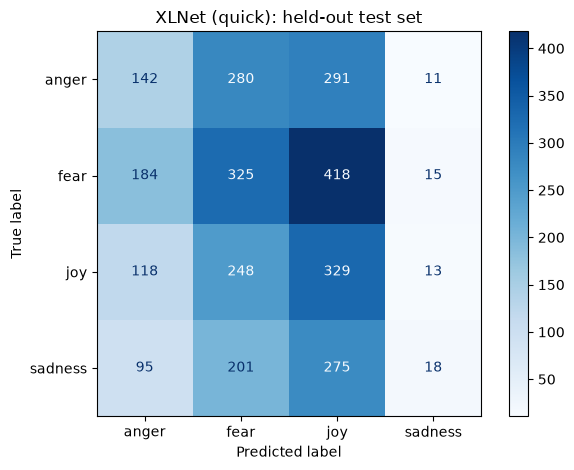

In [11]:
# 即使 quick 模式，仍使用全部独立测试数据；分数衡量的是本次模型。
print(f"正在评估：模式={TRAIN_MODE}，训练样本={len(train_dataset)}，测试样本={len(model_dataset['test'])}", flush=True)
test_result = trainer.predict(model_dataset["test"], metric_key_prefix="test")
test_logits = test_result.predictions
if isinstance(test_logits, tuple):
    test_logits = test_logits[0]
test_predictions = np.argmax(test_logits, axis=-1)
display(pd.DataFrame([test_result.metrics]))
print(classification_report(test_result.label_ids, test_predictions,
                            labels=list(id2label), target_names=label_names, zero_division=0))
ConfusionMatrixDisplay.from_predictions(test_result.label_ids, test_predictions,
    labels=list(id2label), display_labels=label_names, cmap="Blues")
plt.title(f"XLNet ({TRAIN_MODE}): held-out test set")
plt.tight_layout()
plt.show()
trainer.save_metrics("test", test_result.metrics)

## 11. 保存自定义模型、分词器与预处理规则

`final_model` 保存验证集上最佳模型，而非强制保存最后一轮。每次训练目录独立，不覆盖旧结果。恢复训练使用 `checkpoints`，日常推理使用 `final_model`。

In [12]:
# 保存验证集上最佳的权重、分词器及实际配置；目录带模式和时间，不覆盖旧模型。
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
preprocessing_config = {"max_length": MAX_LENGTH, "remove_mentions": True,
    "remove_emoji": True, "lowercase": False, "base_model": MODEL_NAME,
    "label2id": label2id, "seed": SEED,
    "training_mode": TRAIN_MODE, "training_samples": len(train_dataset), "epochs": NUM_EPOCHS}
(MODEL_DIR / "preprocessing_config.json").write_text(
    json.dumps(preprocessing_config, ensure_ascii=False, indent=2), encoding="utf-8")
# 保存清洗函数本身，独立加载模型时不必猜测或重新编写清洗逻辑。
import inspect
(MODEL_DIR / "preprocessing.py").write_text(
    "import re\nfrom cleantext import clean\n\n" + inspect.getsource(clean_for_xlnet), encoding="utf-8")
print("已保存：", MODEL_DIR.resolve())

已保存： D:\Study\AI_Study\Course1_365\34_LLMs使用XLNet进行文本分类\xlnet_runs\quick_20260917_213842_791130\final_model


## 12. 从磁盘重新加载并试用

使用保存目录中的模型、分词器和清洗函数，验证保存结果确实可以使用。示例仅供体验，不能代替上面的独立测试指标。置信分数是 softmax 分数，不保证等于实际正确概率。

In [13]:
from importlib.util import spec_from_file_location, module_from_spec

# 从落盘文件恢复预处理参数，不依赖猜测；重启内核后可将 MODEL_DIR 指向已有目录。
saved_config = json.loads((MODEL_DIR / "preprocessing_config.json").read_text(encoding="utf-8"))
spec = spec_from_file_location("saved_preprocessing", MODEL_DIR / "preprocessing.py")
saved_preprocessing = module_from_spec(spec)
spec.loader.exec_module(saved_preprocessing)
saved_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
saved_model = XLNetForSequenceClassification.from_pretrained(MODEL_DIR, local_files_only=True)
saved_model.eval()  # 默认在 CPU 试用，关闭 dropout。

def predict_emotions(texts):
    """输入一条字符串或字符串列表，返回原文、清洗文本、预测情绪及分数。"""
    if isinstance(texts, str):
        texts = [texts]
    if not isinstance(texts, list) or not all(isinstance(text, str) for text in texts):
        raise TypeError("texts 必须是一条字符串或字符串列表。")
    cleaned = [saved_preprocessing.clean_for_xlnet(text) for text in texts]
    if not cleaned or any(not text for text in cleaned):
        raise ValueError("请输入清洗后仍有文字内容的文本。")
    inputs = saved_tokenizer(cleaned, padding=True, truncation=True,
        max_length=saved_config["max_length"], return_tensors="pt")
    # 推理只计算概率，不反向传播；最大 softmax 值不等于实际正确率。
    with torch.no_grad():
        probabilities = saved_model(**inputs).logits.softmax(dim=-1)
    scores, ids = probabilities.max(dim=-1)
    return pd.DataFrame({"text": texts, "clean_text": cleaned,
        "emotion": [saved_model.config.id2label[i] for i in ids.tolist()],
        "confidence": scores.tolist()})

display(predict_emotions([
    "@friend I am so happy and excited about this wonderful news! ❤️",
    "I am furious. This is completely unfair!",
    "I feel lonely and sad. I miss my family.",
    "I am scared and worried about what will happen tomorrow.",
]))

,text,clean_text,emotion,confidence
0,@friend I am so happy and excited about this w...,I am so happy and excited about this wonderful...,joy,0.393173
1,I am furious. This is completely unfair!,I am furious. This is completely unfair!,sadness,0.285170
2,I feel lonely and sad. I miss my family.,I feel lonely and sad. I miss my family.,fear,0.326678
3,I am scared and worried about what will happen...,I am scared and worried about what will happen...,fear,0.344599
